In [7]:
!pip -q install -U gdown
!gdown --id 10hc7jt7GgSaZ48oz30WM7L_-MP5mrjjC -O dataset.zip

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=10hc7jt7GgSaZ48oz30WM7L_-MP5mrjjC
From (redirected): https://drive.google.com/uc?id=10hc7jt7GgSaZ48oz30WM7L_-MP5mrjjC&confirm=t&uuid=ac96d293-1ba1-4768-a1cf-f9e4bbc29d09
To: /content/dataset.zip
100% 717M/717M [00:09<00:00, 71.8MB/s]


In [9]:
!mv dataset.zip dataset.csv
!ls -lh dataset.csv
!head -n 5 dataset.csv

-rw-r--r-- 1 root root 684M Feb  1 04:13 dataset.csv
Departure Block Hour,Arrival Time Block,Day Of Week,Flight Date,Origin Airport Code,Destination Airport Code,Fly Time Scheduled,Distance Miles,Distance Group,Carrier Delay,Weather Delay,Airport Delay,Security Delay,Late Aircraft Delay,Day of Month,Month,is_delayed,primary_reason,Carrier Delay_log,Weather Delay_log,Airport Delay_log,Security Delay_log,Late Aircraft Delay_log
6,6,1,2023-02-13,144,217,65,137,1,0,0,0,0,0,13,2,0,0,0.0,0.0,0.0,0.0,0.0
6,7,1,2023-02-06,176,57,80,220,1,0,0,0,0,0,6,2,0,0,0.0,0.0,0.0,0.0,0.0
6,7,1,2023-02-06,250,57,60,159,1,0,0,0,0,0,6,2,0,0,0.0,0.0,0.0,0.0,0.0
6,7,1,2023-02-06,160,88,65,239,1,0,0,0,0,0,6,2,0,0,0.0,0.0,0.0,0.0,0.0


In [10]:
import pandas as pd

df = pd.read_csv("dataset.csv")
df.shape, df.head()

((8319194, 23),
    Departure Block Hour  Arrival Time Block  Day Of Week Flight Date  \
 0                     6                   6            1  2023-02-13   
 1                     6                   7            1  2023-02-06   
 2                     6                   7            1  2023-02-06   
 3                     6                   7            1  2023-02-06   
 4                     6                   7            1  2023-02-06   
 
    Origin Airport Code  Destination Airport Code  Fly Time Scheduled  \
 0                  144                       217                  65   
 1                  176                        57                  80   
 2                  250                        57                  60   
 3                  160                        88                  65   
 4                   81                       160                  60   
 
    Distance Miles  Distance Group  Carrier Delay  ...  Late Aircraft Delay  \
 0             137       

In [2]:
directory = "/content/drive/MyDrive/DL-I_term project/Term_project"

In [37]:
!ls -lah 'drive/MyDrive/DL-I_term project/Term_project'

total 684M
-rw-------+ 1 root root 684M Feb  1 04:13 dataset.csv
-rw-------  1 root root  619 Feb  6 13:37 libraries.py
-rw-------  1 root root  12K Feb  6 13:56 Main.ipynb
-rw-------  1 root root   23 Feb  6 13:39 temp.py


In [3]:
import pandas as pd
df_raw = pd.read_csv(f"{directory}/dataset.csv")
df_raw.shape, df_raw.head()

((8319194, 23),
    Departure Block Hour  Arrival Time Block  Day Of Week Flight Date  \
 0                     6                   6            1  2023-02-13   
 1                     6                   7            1  2023-02-06   
 2                     6                   7            1  2023-02-06   
 3                     6                   7            1  2023-02-06   
 4                     6                   7            1  2023-02-06   
 
    Origin Airport Code  Destination Airport Code  Fly Time Scheduled  \
 0                  144                       217                  65   
 1                  176                        57                  80   
 2                  250                        57                  60   
 3                  160                        88                  65   
 4                   81                       160                  60   
 
    Distance Miles  Distance Group  Carrier Delay  ...  Late Aircraft Delay  \
 0             137       

In [4]:
df_raw.columns

Index(['Departure Block Hour', 'Arrival Time Block', 'Day Of Week',
       'Flight Date', 'Origin Airport Code', 'Destination Airport Code',
       'Fly Time Scheduled', 'Distance Miles', 'Distance Group',
       'Carrier Delay', 'Weather Delay', 'Airport Delay', 'Security Delay',
       'Late Aircraft Delay', 'Day of Month', 'Month', 'is_delayed',
       'primary_reason', 'Carrier Delay_log', 'Weather Delay_log',
       'Airport Delay_log', 'Security Delay_log', 'Late Aircraft Delay_log'],
      dtype='object')

In [5]:
cols = df_raw.columns

In [6]:
log_cols = [c for c in cols if c.endswith("_log")]
log_cols

['Carrier Delay_log',
 'Weather Delay_log',
 'Airport Delay_log',
 'Security Delay_log',
 'Late Aircraft Delay_log']

In [7]:
df_raw[log_cols].values

array([[0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ],
       ...,
       [3.25809654, 0.        , 0.        , 0.        , 1.79175947],
       [1.09861229, 0.        , 1.94591015, 0.        , 3.58351894],
       [0.        , 0.        , 0.        , 0.        , 0.        ]])

In [9]:
df_delay = df_raw[df_raw[log_cols].sum(axis=1) > 0].sample(n=1000000, random_state=42)
df_no_delay = df_raw[df_raw[log_cols].sum(axis=1) == 0].sample(n=1000000, random_state=42)
df_new = pd.concat([df_delay, df_no_delay]).reset_index(drop=True)

In [10]:
df_new.columns

Index(['Departure Block Hour', 'Arrival Time Block', 'Day Of Week',
       'Flight Date', 'Origin Airport Code', 'Destination Airport Code',
       'Fly Time Scheduled', 'Distance Miles', 'Distance Group',
       'Carrier Delay', 'Weather Delay', 'Airport Delay', 'Security Delay',
       'Late Aircraft Delay', 'Day of Month', 'Month', 'is_delayed',
       'primary_reason', 'Carrier Delay_log', 'Weather Delay_log',
       'Airport Delay_log', 'Security Delay_log', 'Late Aircraft Delay_log'],
      dtype='object')

In [11]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 23 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   Departure Block Hour      int64  
 1   Arrival Time Block        int64  
 2   Day Of Week               int64  
 3   Flight Date               object 
 4   Origin Airport Code       int64  
 5   Destination Airport Code  int64  
 6   Fly Time Scheduled        int64  
 7   Distance Miles            int64  
 8   Distance Group            int64  
 9   Carrier Delay             int64  
 10  Weather Delay             int64  
 11  Airport Delay             int64  
 12  Security Delay            int64  
 13  Late Aircraft Delay       int64  
 14  Day of Month              int64  
 15  Month                     int64  
 16  is_delayed                int64  
 17  primary_reason            int64  
 18  Carrier Delay_log         float64
 19  Weather Delay_log         float64
 20  Airport Delay_log       

In [21]:
import os
outpath = os.path.join(directory, "data_subset.csv")
df_new.to_csv(outpath, index=False)

In [12]:
from numpy import dtype
corr = df_new.select_dtypes(include=[dtype("int64", "float64")]).corr()

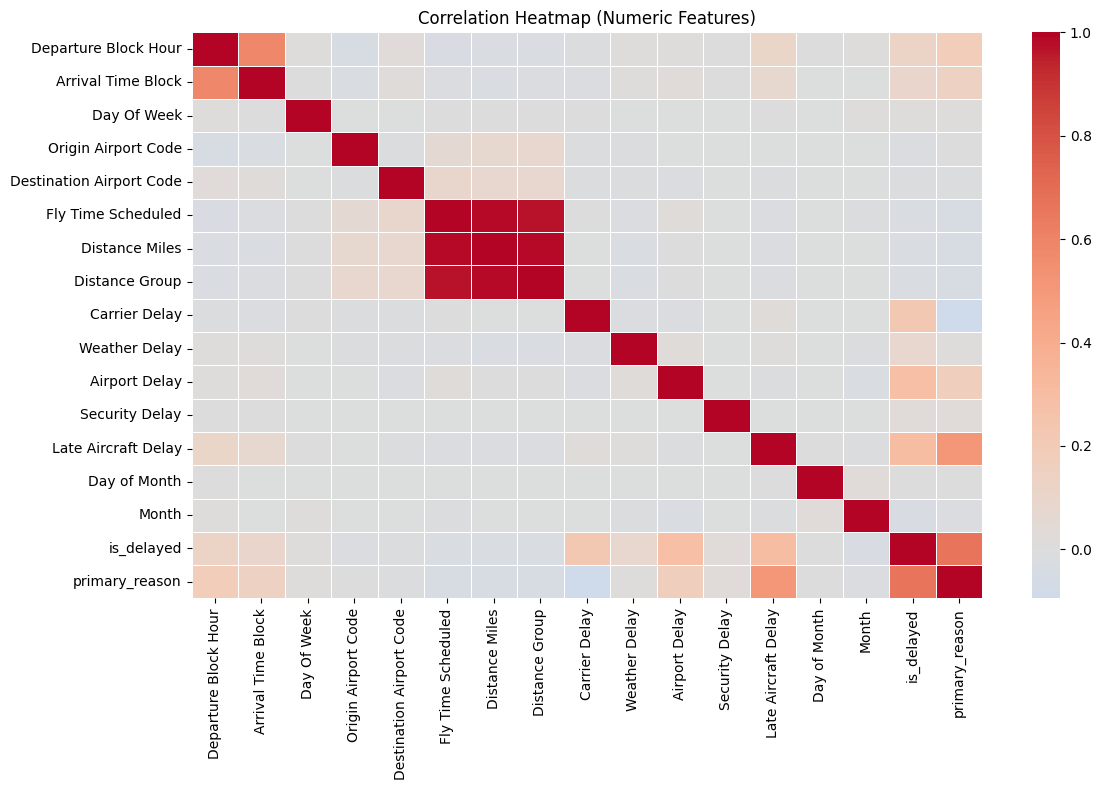

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()

In [14]:
targets = [
    "Carrier Delay_log", "Weather Delay_log", "Airport Delay_log",
    "Security Delay_log", "Late Aircraft Delay_log"
]

leak_cols = [
    "Carrier Delay", "Weather Delay", "Airport Delay", "Security Delay", "Late Aircraft Delay",
    "is_delayed", "primary_reason"
]

keep_one_distance = ["Distance Miles"]

feature_cols = [
    "Departure Block Hour", "Arrival Time Block",
    "Day Of Week", "Day of Month", "Month",
    "Origin Airport Code", "Destination Airport Code",
] + keep_one_distance

In [23]:
X = df_new[feature_cols].copy()
Y = df_new[targets].copy()
# ground-truth minutes for evaluation & reason (NOT used in X)
delay_min_cols = ["Carrier Delay","Weather Delay","Airport Delay","Security Delay","Late Aircraft Delay"]
Y_minutes_true = df_new[delay_min_cols].copy().astype("float32")  # for total delay + reason metrics

In [17]:
from sklearn.model_selection import train_test_split

In [24]:
X_train, X_temp, Y_train, Y_temp, Ym_train, Ym_temp = train_test_split(
    X, Y, Y_minutes_true, test_size=0.2, random_state=42
)
X_val, X_test, Y_val, Y_test, Ym_val, Ym_test = train_test_split(
    X_temp, Y_temp, Ym_temp, test_size=0.5, random_state=42
)

print(X_train.shape, X_val.shape, X_test.shape)

(1600000, 8) (200000, 8) (200000, 8)


In [33]:
import os, numpy as np, pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [36]:
numeric_features = [
    "Departure Block Hour","Arrival Time Block","Day Of Week","Day of Month","Month","Distance Miles"
]
cat_features = ["Origin Airport Code","Destination Airport Code"]

# Inputs
inputs = {}
for col in numeric_features:
    inputs[col] = keras.Input(shape=(1,), name=col, dtype=tf.float32)
for col in cat_features:
    inputs[col] = keras.Input(shape=(1,), name=col, dtype=tf.int32)

# Normalization (fit on train)
normalizer = layers.Normalization()
normalizer.adapt(np.array(X_train[numeric_features], dtype=np.float32))

num_concat = layers.Concatenate()([inputs[c] for c in numeric_features])
num_out = normalizer(num_concat)

# Categorical enc + embedding
def make_embed(colname, vocab):
    lookup = layers.IntegerLookup(vocabulary=vocab, mask_token=None, oov_token=-1)
    x = lookup(inputs[colname])
    # small embedding dimension (simple)
    emb_dim = 8
    x = layers.Embedding(input_dim=lookup.vocabulary_size(), output_dim=emb_dim)(x)
    return layers.Flatten()(x)

origin_vocab = np.unique(X_train["Origin Airport Code"].astype("int32"))
dest_vocab   = np.unique(X_train["Destination Airport Code"].astype("int32"))

origin_emb = make_embed("Origin Airport Code", origin_vocab)
dest_emb   = make_embed("Destination Airport Code", dest_vocab)

# Final feature vector
x = layers.Concatenate()([num_out, origin_emb, dest_emb])

In [40]:
def build_model(n_layers=2, units=128, dropout=0.2, lr=1e-3):
    x_in = x
    h = x_in
    for _ in range(n_layers):
        h = layers.Dense(units, activation="relu")(h)
        h = layers.Dropout(dropout)(h)

    outputs = layers.Dense(len(targets), name="delay_logs")(h)

    model = keras.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="mse",
        metrics=[keras.metrics.MAE]
    )
    return model

In [61]:
import json

In [63]:
# directory to save best model
save_dir = "/content/drive/MyDrive/DL-I_term project/Term_project/runs_ann"
os.makedirs(save_dir, exist_ok=True)

param_grid = [
    {"n_layers": 2, "units": 128, "dropout": 0.2, "lr": 1e-3, "batch": 2048},
    {"n_layers": 3, "units": 128, "dropout": 0.3, "lr": 1e-3, "batch": 2048},
    {"n_layers": 2, "units": 256, "dropout": 0.2, "lr": 5e-4, "batch": 2048},
    {"n_layers": 4, "units": 256, "dropout": 0.4, "lr": 5e-4, "batch": 2048}
]

def to_dict(df_part):
    out = {}
    for col in numeric_features:
        out[col] = np.array(df_part[col], dtype=np.float32)
    for col in cat_features:
        out[col] = np.array(df_part[col], dtype=np.int32)
    return out

train_in = to_dict(X_train)
val_in   = to_dict(X_val)
test_in  = to_dict(X_test)


all_trials = []
best_val = float("inf")
best_model_path = None
best_cfg = None

for i, cfg in enumerate(param_grid, 1):
    trial_name = f"trial_{i:02d}_L{cfg['n_layers']}_U{cfg['units']}_D{cfg['dropout']}_LR{cfg['lr']}"
    trial_dir = os.path.join(save_dir, trial_name)
    os.makedirs(trial_dir, exist_ok=True)

    model_path = os.path.join(trial_dir, "best_model.keras")
    hist_path  = os.path.join(trial_dir, "history.json")
    cfg_path   = os.path.join(trial_dir, "config.json")

    print(f"\n=== Trial {i}/{len(param_grid)}: {trial_name} ===")
    print(cfg)

    model = build_model(**{k: cfg[k] for k in ["n_layers","units","dropout","lr"]})

    callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
        keras.callbacks.ModelCheckpoint(model_path, monitor="val_loss", save_best_only=True),
    ]

    hist = model.fit(
        train_in, Y_train,
        validation_data=(val_in, Y_val),
        epochs=20,
        batch_size=cfg["batch"],
        verbose=1,
        callbacks=callbacks
    )

    history = hist.history
    trial_best = float(np.min(history["val_loss"]))

    with open(hist_path, "w", encoding="utf-8") as f:
        json.dump(history, f, indent=2)
    with open(cfg_path, "w", encoding="utf-8") as f:
        json.dump(cfg, f, indent=2)

    all_trials.append({
        "trial_id": i,
        "name": trial_name,
        "cfg": cfg,
        "history": history,
        "best_val_loss": trial_best,
        "model_path": model_path
    })

    print("trial best val_loss:", trial_best)
    print("saved best model:", model_path)

    # track global best
    if trial_best < best_val:
        best_val = trial_best
        best_model_path = model_path
        best_cfg = cfg

print("\nBEST CONFIG:", best_cfg)
print("BEST VAL LOSS:", best_val)
print("BEST MODEL PATH:", best_model_path)



=== Trial 1/4: trial_01_L2_U128_D0.2_LR0.001 ===
{'n_layers': 2, 'units': 128, 'dropout': 0.2, 'lr': 0.001, 'batch': 2048}
Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 1.3973 - mean_absolute_error: 0.7507 - val_loss: 1.3408 - val_mean_absolute_error: 0.7158
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 1.3438 - mean_absolute_error: 0.7300 - val_loss: 1.3345 - val_mean_absolute_error: 0.7169
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 1.3406 - mean_absolute_error: 0.7281 - val_loss: 1.3322 - val_mean_absolute_error: 0.7222
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 1.3372 - mean_absolute_error: 0.7267 - val_loss: 1.3311 - val_mean_absolute_error: 0.7203
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 1.3344 - mean_absolute_error: 0.7259 - val_loss: 1.3302 - val_mean_absolute_error: 0.7236
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 1.3348 - mean_absolute_error: 0.7263 - val_loss: 1.3297 - val_mean

In [64]:
summary_path = os.path.join(save_dir, "tuning_summary.json")
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(
        {
            "best_val_loss": best_val,
            "best_cfg": best_cfg,
            "best_model_path": best_model_path,
            "trials": [
                {
                    "trial_id": t["trial_id"],
                    "name": t["name"],
                    "best_val_loss": t["best_val_loss"],
                    "cfg": t["cfg"],
                    "model_path": t["model_path"],
                } for t in all_trials
            ],
        },
        f,
        indent=2
    )
print("Saved summary:", summary_path)

Saved summary: /content/drive/MyDrive/DL-I_term project/Term_project/runs_ann/tuning_summary.json


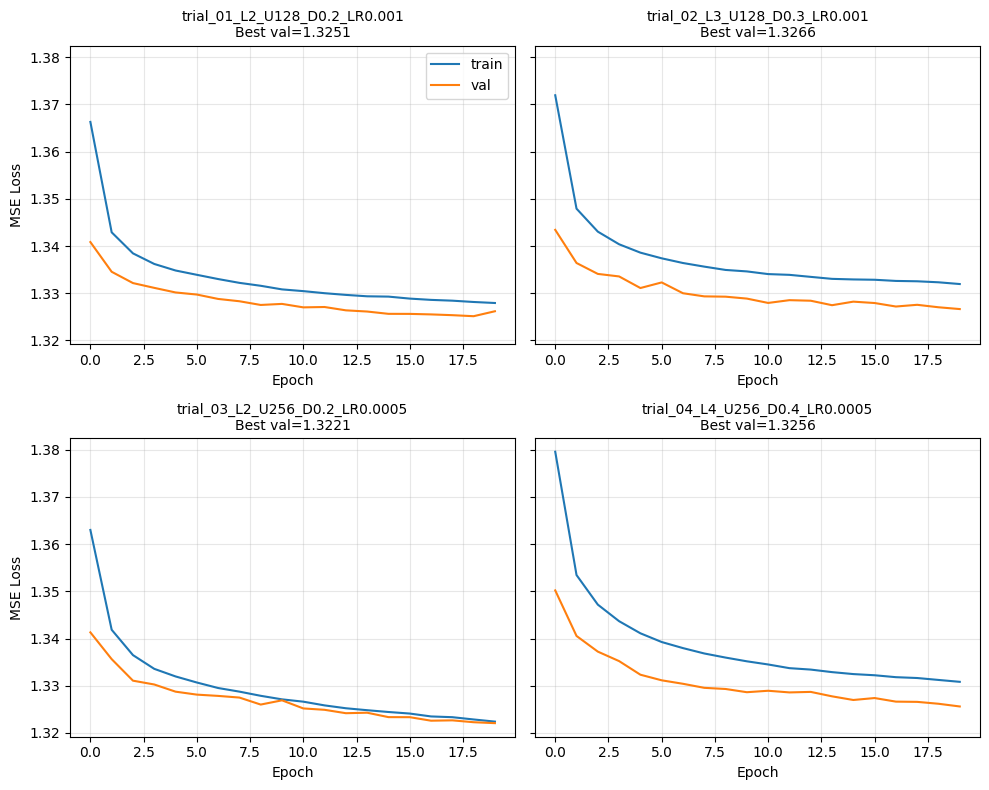

Saved plot: /content/drive/MyDrive/DL-I_term project/Term_project/runs_ann/loss_grid_2x2.png


In [67]:
import os
import matplotlib.pyplot as plt

rows, cols = 2, 2
max_plots = rows * cols

# choose which trials to show (first 4)
trials_to_plot = all_trials[:max_plots]

fig, axes = plt.subplots(rows, cols, figsize=(10, 8), sharey=True)
axes = axes.flatten()

for idx in range(max_plots):
    ax = axes[idx]

    if idx < len(trials_to_plot):
        t = trials_to_plot[idx]
        loss = t["history"]["loss"]
        val_loss = t["history"]["val_loss"]

        ax.plot(loss, label="train")
        ax.plot(val_loss, label="val")
        ax.set_title(f"{t['name']}\nBest val={t['best_val_loss']:.4f}", fontsize=10)
        ax.set_xlabel("Epoch")
        ax.grid(True, alpha=0.3)

        # legend only once (top-left)
        if idx == 0:
            ax.legend()
    else:
        ax.axis("off")

# y-label only on left column for cleanliness
axes[0].set_ylabel("MSE Loss")
axes[2].set_ylabel("MSE Loss")

plt.tight_layout()

side_by_side_path = os.path.join(save_dir, "loss_grid_2x2.png")
plt.savefig(side_by_side_path, dpi=150)
plt.show()
print("Saved plot:", side_by_side_path)

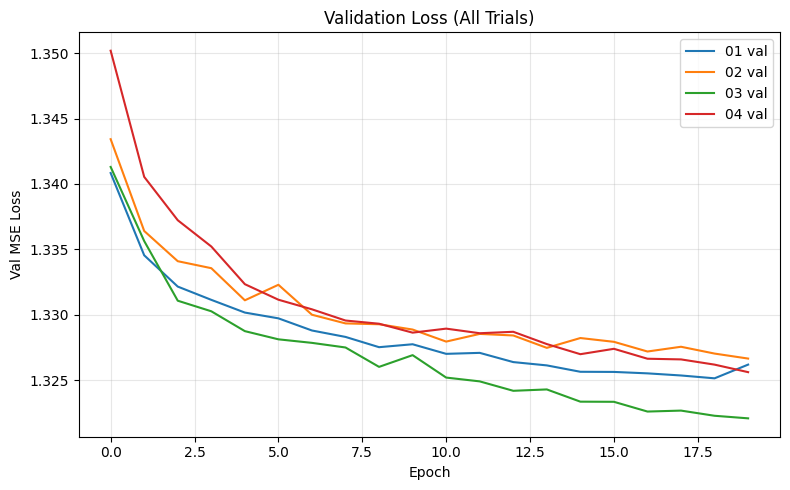

Saved plot: /content/drive/MyDrive/DL-I_term project/Term_project/runs_ann/val_loss_overlay.png


In [66]:
plt.figure(figsize=(8,5))
for t in all_trials:
    plt.plot(t["history"]["val_loss"], label=f"{t['trial_id']:02d} val")
plt.title("Validation Loss (All Trials)")
plt.xlabel("Epoch")
plt.ylabel("Val MSE Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

overlay_path = os.path.join(save_dir, "val_loss_overlay.png")
plt.savefig(overlay_path, dpi=150)
plt.show()
print("Saved plot:", overlay_path)

In [73]:
best_model = keras.models.load_model(best_model_path)

# Predict 5 log targets
Y_pred_log = best_model.predict(test_in, verbose=0)

# Convert to minutes (assuming log1p was used)
Y_pred_min = np.expm1(Y_pred_log)
Y_true_min = Ym_test.values  # raw minutes from dataset

# Total delay minutes
total_pred = Y_pred_min.sum(axis=1)
total_true = Y_true_min.sum(axis=1)

In [74]:

# Regression metrics on total delay
mae_total = mean_absolute_error(total_true, total_pred)
rmse_total = np.sqrt(mean_squared_error(total_true, total_pred))
r2_total = r2_score(total_true, total_pred)

print("\nTOTAL DELAY (minutes) metrics")
print(f"MAE: {mae_total:.2f}")
print(f"RMSE: {rmse_total:.2f}")
print("R2:", r2_total)

# Component-wise MAE
print("\nComponent MAE (minutes):")
for idx, name in enumerate(delay_min_cols):
    mae = mean_absolute_error(Y_true_min[:, idx], Y_pred_min[:, idx])
    print(f"{name:20s} MAE = {mae:.3f}")

# Predicted reason (argmax component)
reason_pred = np.argmax(Y_pred_min, axis=1)
reason_true = np.argmax(Y_true_min, axis=1)
reason_acc = accuracy_score(reason_true, reason_pred)

print("\nReason accuracy (argmax of minutes):", reason_acc)

# Contribution (%) for a sample
eps = 1e-6
contrib = (Y_pred_min / (total_pred[:, None] + eps)) * 100.0
print("\nExample predicted contribution % (first row):")
for i, name in enumerate(delay_min_cols):
    print(f"{name:20s}: {contrib[0, i]:.1f}%")


TOTAL DELAY (minutes) metrics
MAE: 35.37
RMSE: 86.09
R2: -0.14616739749908447

Component MAE (minutes):
Carrier Delay        MAE = 12.947
Weather Delay        MAE = 2.318
Airport Delay        MAE = 7.267
Security Delay       MAE = 0.077
Late Aircraft Delay  MAE = 14.750

Reason accuracy (argmax of minutes): 0.452875

Example predicted contribution % (first row):
Carrier Delay       : 59.2%
Weather Delay       : 1.4%
Airport Delay       : 26.1%
Security Delay      : 0.3%
Late Aircraft Delay : 13.0%


Inference

In [75]:
best_model = keras.models.load_model(best_model_path)

In [76]:
# picking one row from Xtest set
i = 0
x_one = X_test.iloc[[i]]

# convert to model input mode
x_one_in = to_dict(x_one)

# predict log targets
y_pred_log = best_model.predict(x_one_in, verbose=0)

# convert log -> minutes (assuming log1p used)
y_pred_min = np.expm1(y_pred_log)[0]  # shape (5,)
y_pred_min = np.clip(y_pred_min, 0, None)  # safety: no negative minutes

In [77]:
delay_names = ["Carrier Delay", "Weather Delay", "Airport Delay", "Security Delay", "Late Aircraft Delay"]

total_pred = float(y_pred_min.sum())
reason_idx = int(np.argmax(y_pred_min))
reason_pred = delay_names[reason_idx]

contrib = (y_pred_min / (total_pred + 1e-6)) * 100.0

print("Predicted delay minutes by reason:")
for name, mins, pct in zip(delay_names, y_pred_min, contrib):
    print(f"  {name:20s}: {mins:8.2f} min   ({pct:5.1f}%)")

print("\nPredicted TOTAL delay:", f"{total_pred:.2f}", "minutes")
print("Predicted PRIMARY reason:", reason_pred)

Predicted delay minutes by reason:
  Carrier Delay       :     1.55 min   ( 59.2%)
  Weather Delay       :     0.04 min   (  1.4%)
  Airport Delay       :     0.69 min   ( 26.1%)
  Security Delay      :     0.01 min   (  0.3%)
  Late Aircraft Delay :     0.34 min   ( 13.0%)

Predicted TOTAL delay: 2.62 minutes
Predicted PRIMARY reason: Carrier Delay
